<div style="background: linear-gradient(to bottom, #28DCAA, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Model Comparison — Creative Generation
Compares Qwen and DeepSeek coder models (dense & mixture-of-experts, 4-bit/8-bit quantized, run locally via MLX) on creative SVG generation.

</div>

In [ ]:
import gc, json, re, sys, xml.etree.ElementTree as ET
from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from PIL import Image, ImageDraw
import cairosvg

sys.path.insert(0, "..")
from brand import BRAND, blue, purple, orange, green, pink, teal, brown, white, black, dark_bg

plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.facecolor": dark_bg, "axes.facecolor": blue,
    "axes.edgecolor": blue, "axes.labelcolor": white,
    "xtick.color": white, "ytick.color": white, "text.color": white,
    "legend.facecolor": dark_bg, "legend.edgecolor": blue,
})

SYSTEM_PROMPT = (
    "You are an SVG icon generator. "
    "Given a description, output clean, valid SVG code for a single icon. "
    "Use currentColor for fill and stroke so the icon inherits its parent's color. "
    "Output only the SVG element — no explanation, no markdown fences."
)

MODELS = [
    {"id": "mlx-community/Qwen2.5-Coder-7B-Instruct-4bit"},
    {"id": "mlx-community/Qwen2.5.1-Coder-7B-Instruct-4bit"},
    {"id": "mlx-community/Qwen2.5-Coder-7B-Instruct-8bit"},
    {"id": "mlx-community/Qwen2.5-Coder-14B-Instruct-4bit"},
    {"id": "mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit"},  # ~15GB (MoE, 30B total/3B active)
    {"id": "mlx-community/DeepSeek-Coder-V2-Lite-Instruct-4bit"},
    {"id": "our-own"},  # placeholder for our own model
]

#<svg xmlns="http://www.w3.org/2000/svg" width="24" height="24" viewBox="0 0 24 24"><g fill="none" stroke="#000" stroke-linecap="round" stroke-width="1.5"><path stroke-linejoin="round" d="M5 16H3a1 1 0 0 0-1 1v.5a1 1 0 0 0 1 1h1a1 1 0 0 1 1 1v.5a1 1 0 0 1-1 1H2m6.5-5h1a1 1 0 0 1 1 1v3a1 1 0 0 1-1 1h-1a1 1 0 0 1-1-1v-3a1 1 0 0 1 1-1m5.5 0h1a1 1 0 0 1 1 1v3a1 1 0 0 1-1 1h-1a1 1 0 0 1-1-1v-3a1 1 0 0 1 1-1m8 0v5l-3.5-5v5"/><path d="M17 8A5 5 0 1 0 7 8a5 5 0 0 0 10 0Z"/><path stroke-linejoin="round" d="M13.5 8.5L12 8V5.5"/></g></svg>



for m in MODELS:
    m["name"] = m["id"].removeprefix("mlx-community/")

MODEL_COLORS = [pink, orange, green, teal, purple, brown, blue]  # one color per model, Parts 1 & 2

SAMPLE_N = 50  # Part 2 only: number of captioned icons used for metrics

print("Ready. Models:", [m['name'] for m in MODELS])


Ready. Models: ['Qwen2.5-Coder-7B-Instruct-4bit', 'Qwen2.5.1-Coder-7B-Instruct-4bit', 'Qwen2.5-Coder-7B-Instruct-8bit', 'Qwen2.5-Coder-14B-Instruct-4bit', 'Qwen3-Coder-30B-A3B-Instruct-4bit', 'DeepSeek-Coder-V2-Lite-Instruct-4bit', 'our-own']


In [19]:
import re

def clean_svg(raw: str) -> str:
    raw = re.sub(r'```\w*', '', raw)  # strip markdown fences
    raw = raw.replace('<|im_end|>', '')
    return raw.strip()


def generate_svgs(model_cfg: dict, prompts: list[str]) -> list[str]:
    from mlx_lm import load, generate
    from mlx_lm.sample_utils import make_sampler
    print(f"Loading {model_cfg['name']} ...")
    model, tokenizer = load(model_cfg["id"], adapter_path=model_cfg.get("adapter"))
    results = []
    for prompt in prompts:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": prompt},
        ]
        prompt_str = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        raw = generate(model, tokenizer, prompt=prompt_str,
                       max_tokens=2048,  # 2× real-world max (~3500 chars ≈ 1000 tokens); prevents runaway without cutting valid SVGs
                       sampler=make_sampler(temp=0.7), verbose=False)
        results.append(clean_svg(raw))
    del model, tokenizer
    gc.collect()
    print(f"  done ({len(results)} icons)")
    return results


CARD_SIZE     = 200
CORNER_RADIUS = 18
ICON_PADDING  = 20

def svg_to_card(svg: str, icon_color: str, label: str = "") -> Image.Image | None:
    try:
        icon_size = CARD_SIZE - ICON_PADDING * 2
        # replace currentColor and hardcoded black (models often omit currentColor and default to black)
        svg_colored = svg.replace("currentColor", icon_color)
        svg_colored = re.sub(r'(fill|stroke)="(black|#000|#000000)"', rf'\1="{icon_color}"', svg_colored)
        png = cairosvg.svg2png(bytestring=svg_colored.encode(),
                               output_width=icon_size, output_height=icon_size)
        icon = Image.open(BytesIO(png)).convert("RGBA")

        card = Image.new("RGBA", (CARD_SIZE, CARD_SIZE), (0, 0, 0, 0))
        mask = Image.new("L", (CARD_SIZE, CARD_SIZE), 0)
        ImageDraw.Draw(mask).rounded_rectangle(
            [0, 0, CARD_SIZE - 1, CARD_SIZE - 1], radius=CORNER_RADIUS, fill=255
        )
        white = Image.new("RGBA", (CARD_SIZE, CARD_SIZE), (255, 255, 255, 255))
        card.paste(white, mask=mask)
        card.paste(icon, (ICON_PADDING, ICON_PADDING), icon)
        return card
    except Exception as e:
        tag = f" [{label}]" if label else ""
        print(f"render error{tag}: {e}")
        return None


## Part 1 — Creative Generation

10 prompts × each model. Images rendered at 128 px.

In [20]:
PROMPTS = [
    "Monochrome SVG icon of a robot head wearing headset",
    "Monochrome SVG icon of a human-robot handshake",
    "Monochrome SVG icon of a multi-agent system",
    "Monochrome SVG icon of a robot reading a book",
]

In [21]:
import time

creative_results: dict[str, list[str]] = {}
generation_times: dict[str, float] = {}
for cfg in MODELS:
    if cfg["id"] == "our-own":
        continue
    t0 = time.time()
    creative_results[cfg["name"]] = generate_svgs(cfg, PROMPTS)
    elapsed = time.time() - t0
    generation_times[cfg["name"]] = elapsed
    print(f"  {cfg['name']}: {elapsed:.1f}s ({elapsed/len(PROMPTS):.1f}s/icon)")


Loading Qwen2.5-Coder-7B-Instruct-4bit ...


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 85019.68it/s]


  done (4 icons)
  Qwen2.5-Coder-7B-Instruct-4bit: 69.5s (17.4s/icon)
Loading Qwen2.5.1-Coder-7B-Instruct-4bit ...


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 163414.44it/s]


  done (4 icons)
  Qwen2.5.1-Coder-7B-Instruct-4bit: 17.2s (4.3s/icon)
Loading Qwen2.5-Coder-7B-Instruct-8bit ...


...

  done (4 icons)
  Qwen2.5-Coder-14B-Instruct-4bit: 41.5s (10.4s/icon)
Loading Qwen3-Coder-30B-A3B-Instruct-4bit ...


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 24837.96it/s]


[WARNING] Generating with a model that requires 16384 MB which is close to the maximum recommended size of 18186 MB. This can be slow. See the documentation for possible work-arounds: https://github.com/ml-explore/mlx-lm/tree/main#large-models
[WARNING] Generating with a model that requires 16384 MB which is close to the maximum recommended size of 18186 MB. This can be slow. See the documentation for possible work-arounds: https://github.com/ml-explore/mlx-lm/tree/main#large-models
[WARNING] Generating with a model that requires 16384 MB which is close to the maximum recommended size of 18186 MB. This can be slow. See the documentation for possible work-arounds: https://github.com/ml-explore/mlx-lm/tree/main#large-models
[WARNING] Generating with a model that requires 16384 MB which is close to the maximum recommended size of 18186 MB. This can be slow. See the documentation for possible work-arounds: https://github.com/ml-explore/mlx-lm/tree/main#large-models
  done (4 icons)
  Qwen3

Fetching 11 files: 100%|██████████| 11/11 [00:00<00:00, 57313.47it/s]
`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


  done (4 icons)
  DeepSeek-Coder-V2-Lite-Instruct-4bit: 15.6s (3.9s/icon)


In [22]:
# Debug: print raw model output to check if SVG is being generated
for model_name, svgs in creative_results.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    for prompt, svg in zip(PROMPTS, svgs):
        print(f"\nPrompt: {prompt}")
        print(f"Output ({len(svg)} chars):")
        print(svg)
        #print("..." if len(svg) > 500 else "")


MODEL: Qwen2.5-Coder-7B-Instruct-4bit

Prompt: Monochrome SVG icon of a robot head wearing headset
Output (584 chars):
<svg viewBox="0 0 24 24" xmlns="http://www.w3.org/2000/svg">
  <path d="M12 2C6.48 2 2 6.48 2 12s4.48 10 10 10 10-4.48 10-10S17.52 2 12 2zm0 3c1.1 0 2 .9 2 2s-.9 2-2 2-2-.9-2-2 .9-2 2-2zm0 12c-1.1 0-2-.9-2-2s.9-2 2-2 2 .9 2 2-.9 2-2 2zm4-2c0 1.1-.9 2-2 2-1.1 0-2-.9-2-2s.9-2 2-2 2 .9 2 2zm-4 2c0 1.1-.9 2-2 2-1.1 0-2-.9-2-2s.9-2 2-2 2 .9 2 2z"/>
  <circle cx="10" cy="10" r="3" fill="currentColor"/>
  <path d="M14 9v2h2v2h-2v2h-2v-2h-2v-2h2v-2h2v2h2z" fill="currentColor"/>
  <path d="M16 14a2 2 0 1 1 0-4 2 2 0 0 1 0 4zm0 2a4 4 0 1 0 0-8 4 4 0 0 0 0 8z" fill="currentColor"/>
</svg>

Prompt: Monochrome SVG icon of a human-robot handshake
Output (278 chars):
<svg width="24" height="24" viewBox="0 0 24 24" fill="currentColor" stroke="currentColor">
  <path d="M12 17L15 20 14.54 19.54 12 17z"/>
  <path d="M12 5L15 8 14.54 8.46 12 10z"/>
  <path d="M8.54 19.54L9 20l1.46-1.46L8

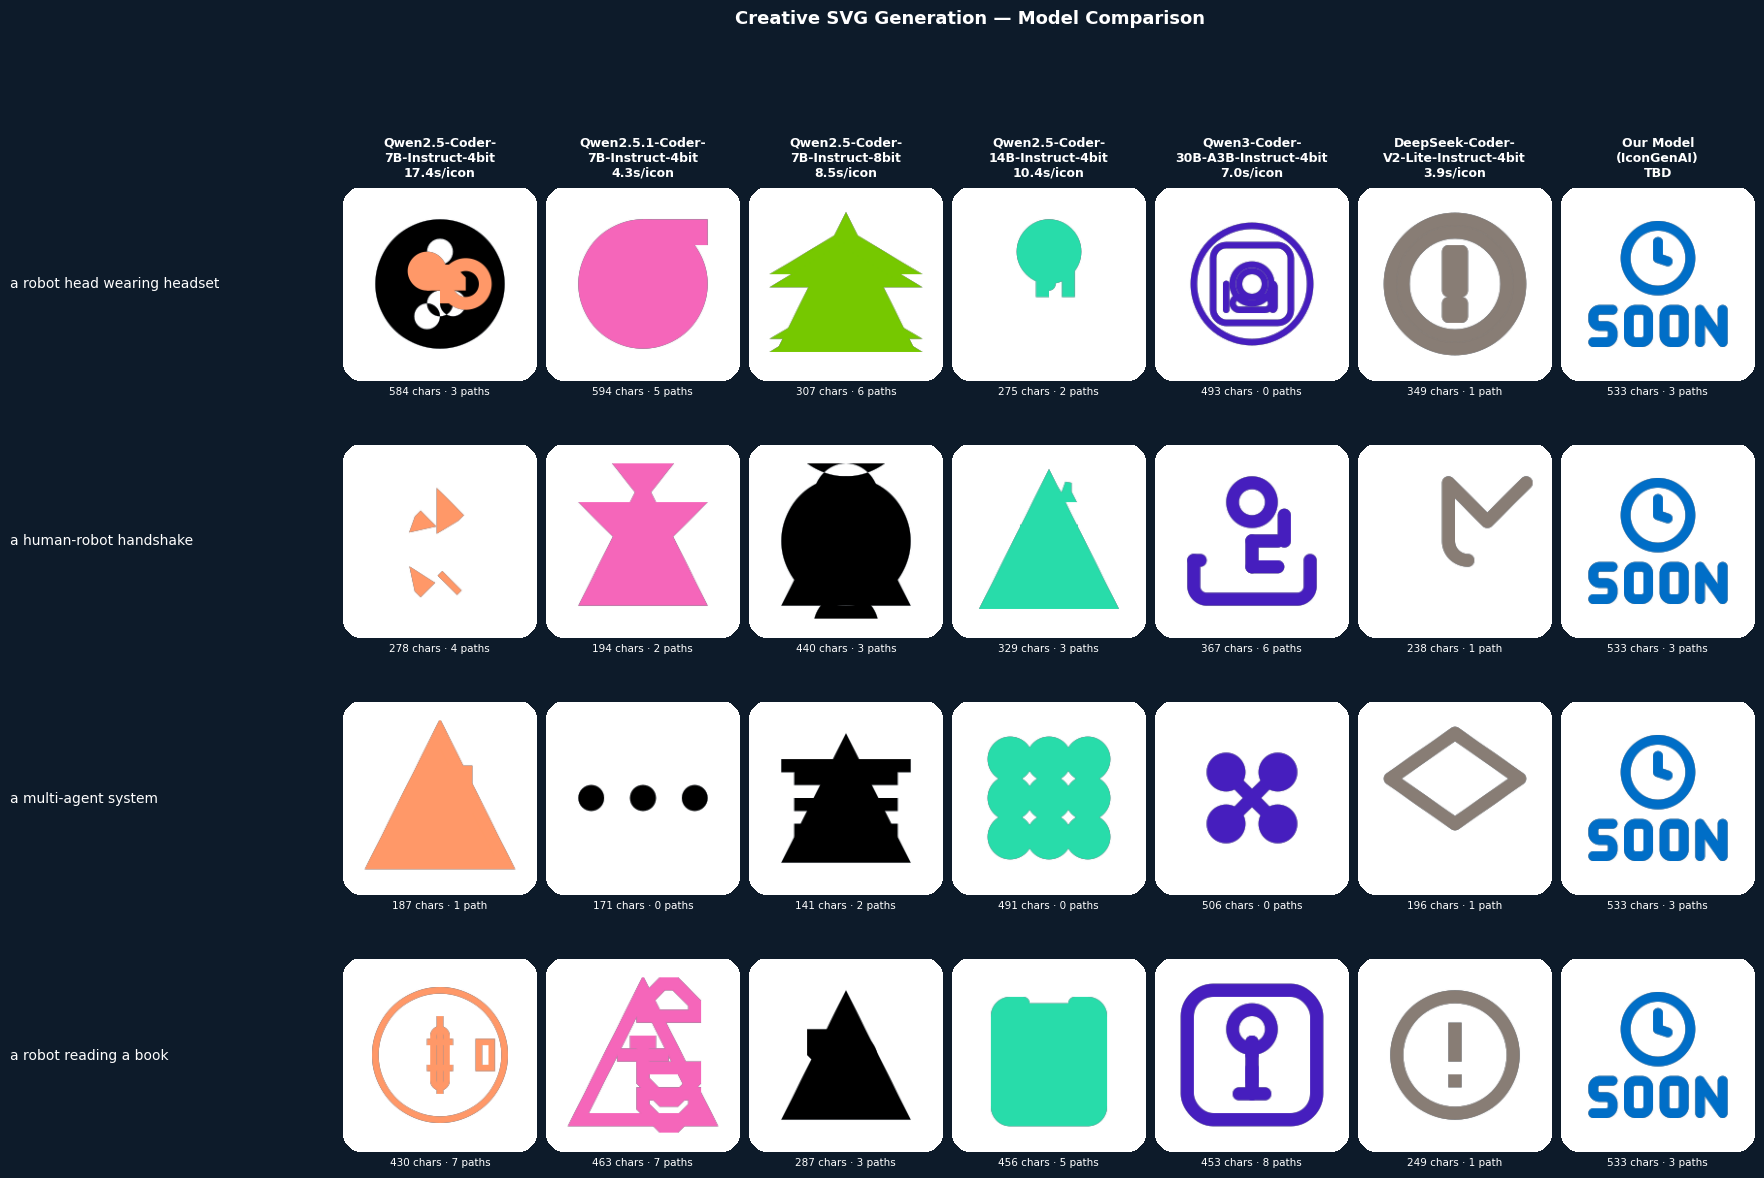

In [23]:
def _path_count(svg: str) -> int:
    try:
        root = ET.fromstring(svg)
        ns = root.tag.split("}")[0].lstrip("{") if "}" in root.tag else ""
        tag = f"{{{ns}}}path" if ns else "path"
        return len(root.findall(f".//{tag}"))
    except Exception:
        return 0

def _fmt_model_name(name: str) -> str:
    # break after 'Coder-' for readable column headers
    return re.sub(r'(Coder-)', r'\1\n', name)

_PLACEHOLDER_SVG = '<svg xmlns="http://www.w3.org/2000/svg" width="24" height="24" viewBox="0 0 24 24"><g fill="none" stroke="#000" stroke-linecap="round" stroke-width="1.5"><path stroke-linejoin="round" d="M5 16H3a1 1 0 0 0-1 1v.5a1 1 0 0 0 1 1h1a1 1 0 0 1 1 1v.5a1 1 0 0 1-1 1H2m6.5-5h1a1 1 0 0 1 1 1v3a1 1 0 0 1-1 1h-1a1 1 0 0 1-1-1v-3a1 1 0 0 1 1-1m5.5 0h1a1 1 0 0 1 1 1v3a1 1 0 0 1-1 1h-1a1 1 0 0 1-1-1v-3a1 1 0 0 1 1-1m8 0v5l-3.5-5v5"/><path d="M17 8A5 5 0 1 0 7 8a5 5 0 0 0 10 0Z"/><path stroke-linejoin="round" d="M13.5 8.5L12 8V5.5"/></g></svg>'
creative_results.setdefault("our-own", [_PLACEHOLDER_SVG] * len(PROMPTS))
generation_times.setdefault("our-own", None)

n_models  = len(MODELS)
n_prompts = len(PROMPTS)

fig, axes = plt.subplots(
    n_prompts, n_models,
    figsize=(n_models * 2.8, n_prompts * 3.0 + 1.2),
    facecolor=dark_bg, squeeze=False,
)
fig.subplots_adjust(left=0.18, top=0.85, hspace=0.25, wspace=0.05)

for c_idx, cfg in enumerate(MODELS):
    is_ours    = cfg["id"] == "our-own"
    svgs       = creative_results[cfg["name"]]
    avg_t      = generation_times[cfg["name"]]
    timing_str = f"{avg_t / len(PROMPTS):.1f}s/icon" if avg_t is not None else "TBD"
    display_name = "Our Model\n(IconGenAI)" if is_ours else _fmt_model_name(cfg["name"])

    for r, (svg, prompt) in enumerate(zip(svgs, PROMPTS)):
        ax = axes[r][c_idx]
        ax.set_facecolor(dark_bg)
        card = svg_to_card(svg, MODEL_COLORS[c_idx % len(MODEL_COLORS)],
                           label=f"{cfg['name']} / {prompt}")
        if card:
            ax.imshow(card)
        else:
            ax.text(0.5, 0.5, "failed", ha="center", va="center",
                    color=white, fontsize=8, transform=ax.transAxes)
        ax.axis("off")

        # per-icon stats below each card
        n_chars = len(svg)
        n_paths = _path_count(svg)
        ax.text(0.5, -0.03, f"{n_chars:,} chars · {n_paths} path{'s' if n_paths != 1 else ''}",
                ha="center", va="top", fontsize=7.5, color=white,
                transform=ax.transAxes, clip_on=False)

        # row label: prompt on the left (first column only)
        if c_idx == 0:
            short = prompt.replace("Monochrome SVG icon of ", "")
            pos = ax.get_position()
            fig.text(
                0.01, pos.y0 + pos.height / 2, short,
                ha="left", va="center", fontsize=10, color=white,
                rotation=0, multialignment="center",
            )

    # column header: model name (broken after Coder-) + timing
    axes[0][c_idx].set_title(f"{display_name}\n{timing_str}",
                             fontsize=9, color=white, fontweight="bold", pad=8)

plt.suptitle("Creative SVG Generation — Model Comparison",
             fontsize=13, color=white, fontweight="bold")
plt.savefig("output/model_comparison_grid.png", dpi=300, bbox_inches="tight", facecolor=dark_bg)
plt.show()
